In [51]:
# Installations and API Imports
!pip install sodapy
from sodapy import Socrata
import pandas as pd
import numpy as np
from sodapy import Socrata
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Connection to Socrata API

baseURL = "data.cityofnewyork.us"
appToken = "Mo7LzE5lFoTeSd1B8KohlOuDu"
dataset_id = "erm2-nwe9"

client = Socrata(baseURL, appToken, timeout=60)

In [ ]:
# Data Retrieval and Filtering

results = client.get(dataset_id,limit=15000,where="""borough='MANHATTAN'AND complaint_type='Noise'AND created_date > '2023-01-01'""")

df = pd.DataFrame.from_records(results)
df.head(15000)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,intersection_street_1,intersection_street_2
0,65240241,2025-06-11T21:56:00.000,2025-06-13T23:30:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10022,229 EAST 55 STREET,EAST 55 STREET,...,993201,215667,ONLINE,Unspecified,MANHATTAN,40.7586280458661,-73.96769023377328,"{'latitude': '40.7586280458661', 'longitude': ...",NaN,NaN
1,66817780,2025-11-12T10:35:00.000,2025-11-18T14:00:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Equipment (NC1),10035,101 EAST 119 STREET,EAST 119 STREET,...,1000455,231144,ONLINE,Unspecified,MANHATTAN,40.801097987914055,-73.94146868060538,"{'latitude': '40.801097987914055', 'longitude'...",NaN,NaN
2,66880928,2025-11-18T23:02:00.000,2025-11-21T17:25:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10012,290 MULBERRY STREET,MULBERRY STREET,...,985628,203300,ONLINE,Unspecified,MANHATTAN,40.72468813514157,-73.99502846808386,"{'latitude': '40.72468813514157', 'longitude':...",NaN,NaN
3,66882355,2025-11-18T23:50:00.000,2025-11-21T17:26:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10026,41 WEST 117 STREET,WEST 117 STREET,...,998694,231521,ONLINE,Unspecified,MANHATTAN,40.802135803695904,-73.94782847605441,"{'latitude': '40.802135803695904', 'longitude'...",NaN,NaN
4,66891933,2025-11-19T09:50:00.000,2025-11-20T15:00:00.000,DEP,Department of Environmental Protection,Noise,Noise: Alarms (NR3),10018,260 WEST 36 STREET,WEST 36 STREET,...,986650,213602,ONLINE,Unspecified,MANHATTAN,40.7529643518705,-73.99133763329309,"{'latitude': '40.7529643518705', 'longitude': ...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,61202510,2024-05-19T20:53:00.000,2024-05-20T08:12:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10011,NaN,NaN,...,985323,210128,ONLINE,Unspecified,MANHATTAN,40.74342935659419,-73.99612775448603,"{'latitude': '40.74342935659419', 'longitude':...",7 AVENUE,WEST 22 STREET
14996,63208369,2024-11-25T19:20:00.000,2024-11-26T17:10:00.000,DEP,Department of Environmental Protection,Noise,Noise: air condition/ventilation equipment (NV1),10011,200 WEST 14 STREET,WEST 14 STREET,...,984219,208414,ONLINE,Unspecified,MANHATTAN,40.73872491814651,-74.00011186499094,"{'latitude': '40.73872491814651', 'longitude':...",NaN,NaN
14997,61196846,2024-05-18T20:35:00.000,2024-05-20T08:02:00.000,DEP,Department of Environmental Protection,Noise,Noise: Jack Hammering (NC2),10005,40 EXCHANGE PLACE,EXCHANGE PLACE,...,981417,196461,ONLINE,Unspecified,MANHATTAN,40.705916369634544,-74.01021798535831,"{'latitude': '40.705916369634544', 'longitude'...",NaN,NaN
14998,61207155,2024-05-19T21:08:00.000,2024-05-20T08:06:00.000,DEP,Department of Environmental Protection,Noise,Noise: Construction Equipment (NC1),10022,NaN,NaN,...,993063,216978,ONLINE,Unspecified,MANHATTAN,40.76222654302536,-73.96818664354069,"{'latitude': '40.76222654302536', 'longitude':...",EAST 59 STREET,LEXINGTON AVENUE


In [ ]:
# CSV File Conversion and Data Cleaning 

df.to_csv("raw_311_data.csv", index=False)
df = pd.read_csv("raw_311_data.csv")

#Removal of duplicates

df = df.drop_duplicates()

#Date conversion

df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df["closed_date"] = pd.to_datetime(df["closed_date"], errors="coerce")

# Numerical column conversion

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Removal of unnecessary columns

df = df.drop(columns=["address_type","resolution_description","intersection_street_1","intersection_street_2"], errors="ignore")

df.head(15000)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location
0,65240241,2025-06-11 21:56:00,2025-06-13 23:30:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10022.0,229 EAST 55 STREET,EAST 55 STREET,...,1.013290e+09,MANHATTAN,993201.0,215667.0,ONLINE,Unspecified,MANHATTAN,40.758628,-73.967690,"{'latitude': '40.7586280458661', 'longitude': ..."
1,66817780,2025-11-12 10:35:00,2025-11-18 14:00:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Equipment (NC1),10035.0,101 EAST 119 STREET,EAST 119 STREET,...,1.017680e+09,MANHATTAN,1000455.0,231144.0,ONLINE,Unspecified,MANHATTAN,40.801098,-73.941469,"{'latitude': '40.801097987914055', 'longitude'..."
2,66880928,2025-11-18 23:02:00,2025-11-21 17:25:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10012.0,290 MULBERRY STREET,MULBERRY STREET,...,1.005090e+09,MANHATTAN,985628.0,203300.0,ONLINE,Unspecified,MANHATTAN,40.724688,-73.995028,"{'latitude': '40.72468813514157', 'longitude':..."
3,66882355,2025-11-18 23:50:00,2025-11-21 17:26:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10026.0,41 WEST 117 STREET,WEST 117 STREET,...,1.016010e+09,MANHATTAN,998694.0,231521.0,ONLINE,Unspecified,MANHATTAN,40.802136,-73.947828,"{'latitude': '40.802135803695904', 'longitude'..."
4,66891933,2025-11-19 09:50:00,2025-11-20 15:00:00,DEP,Department of Environmental Protection,Noise,Noise: Alarms (NR3),10018.0,260 WEST 36 STREET,WEST 36 STREET,...,1.007850e+09,MANHATTAN,986650.0,213602.0,ONLINE,Unspecified,MANHATTAN,40.752964,-73.991338,"{'latitude': '40.7529643518705', 'longitude': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,61202510,2024-05-19 20:53:00,2024-05-20 08:12:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),10011.0,NaN,NaN,...,NaN,MANHATTAN,985323.0,210128.0,ONLINE,Unspecified,MANHATTAN,40.743429,-73.996128,"{'latitude': '40.74342935659419', 'longitude':..."
14996,63208369,2024-11-25 19:20:00,2024-11-26 17:10:00,DEP,Department of Environmental Protection,Noise,Noise: air condition/ventilation equipment (NV1),10011.0,200 WEST 14 STREET,WEST 14 STREET,...,1.006180e+09,MANHATTAN,984219.0,208414.0,ONLINE,Unspecified,MANHATTAN,40.738725,-74.000112,"{'latitude': '40.73872491814651', 'longitude':..."
14997,61196846,2024-05-18 20:35:00,2024-05-20 08:02:00,DEP,Department of Environmental Protection,Noise,Noise: Jack Hammering (NC2),10005.0,40 EXCHANGE PLACE,EXCHANGE PLACE,...,1.000250e+09,MANHATTAN,981417.0,196461.0,ONLINE,Unspecified,MANHATTAN,40.705916,-74.010218,"{'latitude': '40.705916369634544', 'longitude'..."
14998,61207155,2024-05-19 21:08:00,2024-05-20 08:06:00,DEP,Department of Environmental Protection,Noise,Noise: Construction Equipment (NC1),10022.0,NaN,NaN,...,NaN,MANHATTAN,993063.0,216978.0,ONLINE,Unspecified,MANHATTAN,40.762227,-73.968187,"{'latitude': '40.76222654302536', 'longitude':..."


In [ ]:
# Data Analysis and Statistical Methods

df["year"] = df["created_date"].dt.year
df["month"] = df["created_date"].dt.month
df["day_of_week"] = df["created_date"].dt.day_name()
df.describe(include="all")

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,year,month,day_of_week
count,1.500000e+04,15000,14677,15000,15000,15000,15000,14998.000000,13190,13190,...,14734.000000,15000,15000,15000,14734.000000,14734.000000,14734,15000.000000,15000.000000,15000
unique,NaN,NaN,NaN,1,1,1,13,NaN,6575,647,...,NaN,2,1,1,NaN,NaN,7268,NaN,NaN,7
top,NaN,NaN,NaN,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),NaN,1530 BROADWAY,BROADWAY,...,NaN,ONLINE,Unspecified,MANHATTAN,NaN,NaN,"{'latitude': '40.75767370013583', 'longitude':...",NaN,NaN,Tuesday
freq,NaN,NaN,NaN,15000,15000,15000,6661,NaN,108,505,...,NaN,12203,15000,15000,NaN,NaN,108,NaN,NaN,2487
mean,6.505262e+07,2025-05-26 10:18:32.952000,2025-05-27 12:41:23.448933632,NaN,NaN,NaN,NaN,10028.470729,NaN,NaN,...,217812.239582,NaN,NaN,NaN,40.764516,-73.975050,NaN,2024.764200,8.141267,NaN
min,5.738909e+07,2023-04-22 22:59:00,2023-04-26 12:30:00,NaN,NaN,NaN,NaN,10000.000000,NaN,NaN,...,189357.000000,NaN,NaN,NaN,40.686415,-74.025979,NaN,2023.000000,1.000000,NaN
25%,6.509428e+07,2025-05-29 07:44:00,2025-06-01 13:30:00,NaN,NaN,NaN,NaN,10012.000000,NaN,NaN,...,207826.000000,NaN,NaN,NaN,40.737111,-73.991463,NaN,2025.000000,6.000000,NaN
50%,6.588758e+07,2025-08-18 17:16:00,2025-08-20 14:27:00,NaN,NaN,NaN,NaN,10022.000000,NaN,NaN,...,216447.000000,NaN,NaN,NaN,40.760771,-73.978152,NaN,2025.000000,9.000000,NaN
75%,6.650320e+07,2025-10-16 07:27:30,2025-10-17 15:54:00,NaN,NaN,NaN,NaN,10031.000000,NaN,NaN,...,225855.000000,NaN,NaN,NaN,40.786594,-73.956554,NaN,2025.000000,10.000000,NaN
max,6.710750e+07,2025-12-08 23:59:00,2025-12-08 23:30:00,NaN,NaN,NaN,NaN,10463.000000,NaN,NaN,...,258969.000000,NaN,NaN,NaN,40.877450,-73.908843,NaN,2025.000000,12.000000,NaN


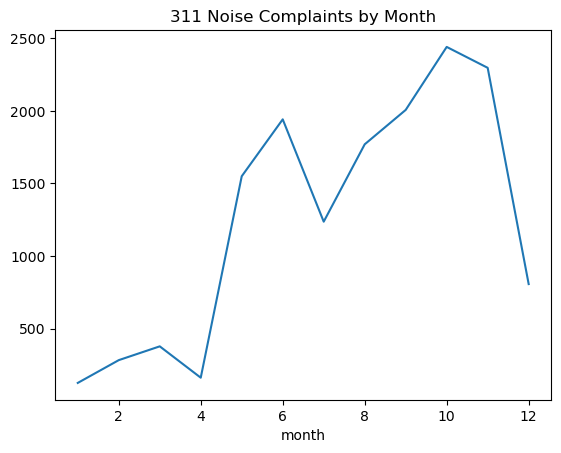

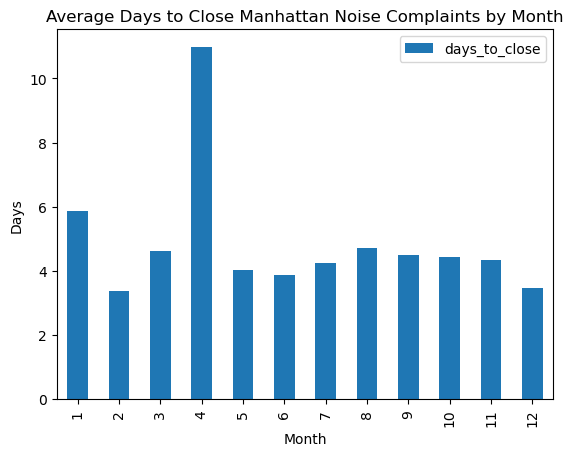

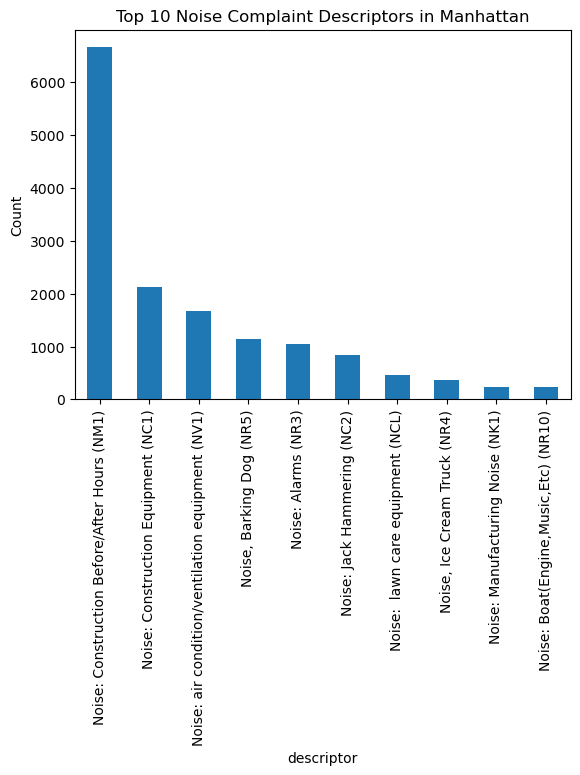

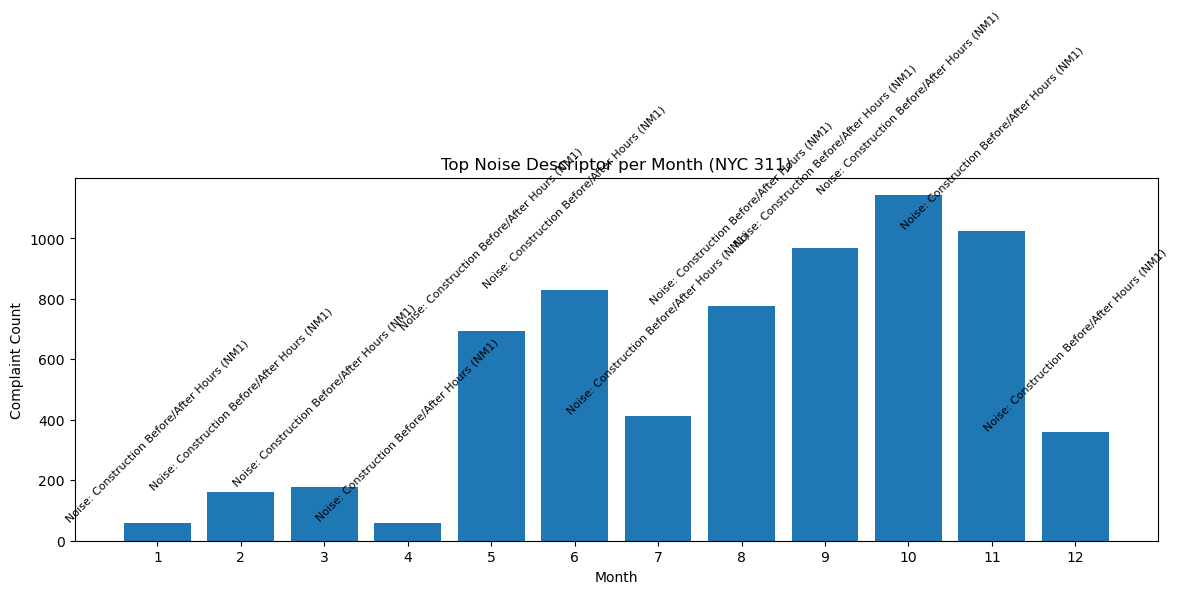

In [ ]:
# Data Visualization

df["month"].value_counts().sort_index().plot(kind="line")
plt.title("311 Noise Complaints by Month")
plt.show()

pivot.plot(kind="bar")
plt.title("Average Days to Close Manhattan Noise Complaints by Month")
plt.ylabel("Days")
plt.xlabel("Month")
plt.show()

df["descriptor"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Noise Complaint Descriptors in Manhattan")
plt.ylabel("Count")
plt.show()

grouped = (df.groupby(['month', 'descriptor']).size().reset_index(name='count'))
top_per_month = (grouped.sort_values(['month', 'count'], ascending=[True, False]).groupby('month').first().reset_index())

plt.figure(figsize=(12,6))
plt.bar(top_per_month['month'], top_per_month['count'])

for i, row in top_per_month.iterrows():
    plt.text(row['month'], row['count'], row['descriptor'],
             ha='center', va='bottom', rotation=45, fontsize=8)

plt.title("Top Noise Descriptor per Month (NYC 311)")
plt.xlabel("Month")
plt.ylabel("Complaint Count")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()